In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv("Loan Delinquent Dataset.csv")
print(df)

          ID delinquent  Sdelinquent       term  gender   purpose  \
0          1        Yes            1  36 months  Female     House   
1          2         No            0  36 months  Female     House   
2          3        Yes            1  36 months  Female     House   
3          4        Yes            1  36 months  Female       Car   
4          5        Yes            1  36 months  Female     House   
...      ...        ...          ...        ...     ...       ...   
11543  11544         No            0  60 months    Male     other   
11544  11545        Yes            1  36 months    Male     House   
11545  11546         No            0  36 months  Female  Personal   
11546  11547        Yes            1  36 months  Female     House   
11547  11548        Yes            1  36 months    Male  Personal   

      home_ownership    age     FICO  
0           Mortgage    >25  300-500  
1               Rent  20-25     >500  
2               Rent    >25  300-500  
3           Mor

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
df=pd.read_csv("Loan Delinquent Dataset.csv")
df.head()

,ID,delinquent,Sdelinquent,term,gender,purpose,home_ownership,age,FICO
0,1,Yes,1,36 months,Female,House,Mortgage,>25,300-500
1,2,No,0,36 months,Female,House,Rent,20-25,>500
2,3,Yes,1,36 months,Female,House,Rent,>25,300-500
3,4,Yes,1,36 months,Female,Car,Mortgage,>25,300-500
4,5,Yes,1,36 months,Female,House,Rent,>25,300-500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11548 entries, 0 to 11547
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              11548 non-null  int64 
 1   delinquent      11548 non-null  object
 2   Sdelinquent     11548 non-null  int64 
 3   term            11548 non-null  object
 4   gender          11548 non-null  object
 5   purpose         11548 non-null  object
 6   home_ownership  11548 non-null  object
 7   age             11548 non-null  object
 8   FICO            11548 non-null  object
dtypes: int64(2), object(7)
memory usage: 812.1+ KB


In [5]:
# Drop unwanted columns
df=df.drop(columns=["ID", "delinquent"])

In [6]:
# Automatically select columns with object or category dtype
categorical_columns = df.select_dtypes(include=['object']).columns

In [7]:
# converting category to numerical variable to build ML model
# label Encoding:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [8]:
from sklearn.preprocessing import LabelEncoder
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    

In [9]:
df.head()

,Sdelinquent,term,gender,purpose,home_ownership,age,FICO
0,1,0,0,1,0,1,0
1,0,0,0,1,2,0,1
2,1,0,0,1,2,1,0
3,1,0,0,0,0,1,0
4,1,0,0,1,2,1,0


In [10]:
label_encoders

{'term': LabelEncoder(),
 'gender': LabelEncoder(),
 'purpose': LabelEncoder(),
 'home_ownership': LabelEncoder(),
 'age': LabelEncoder(),
 'FICO': LabelEncoder()}

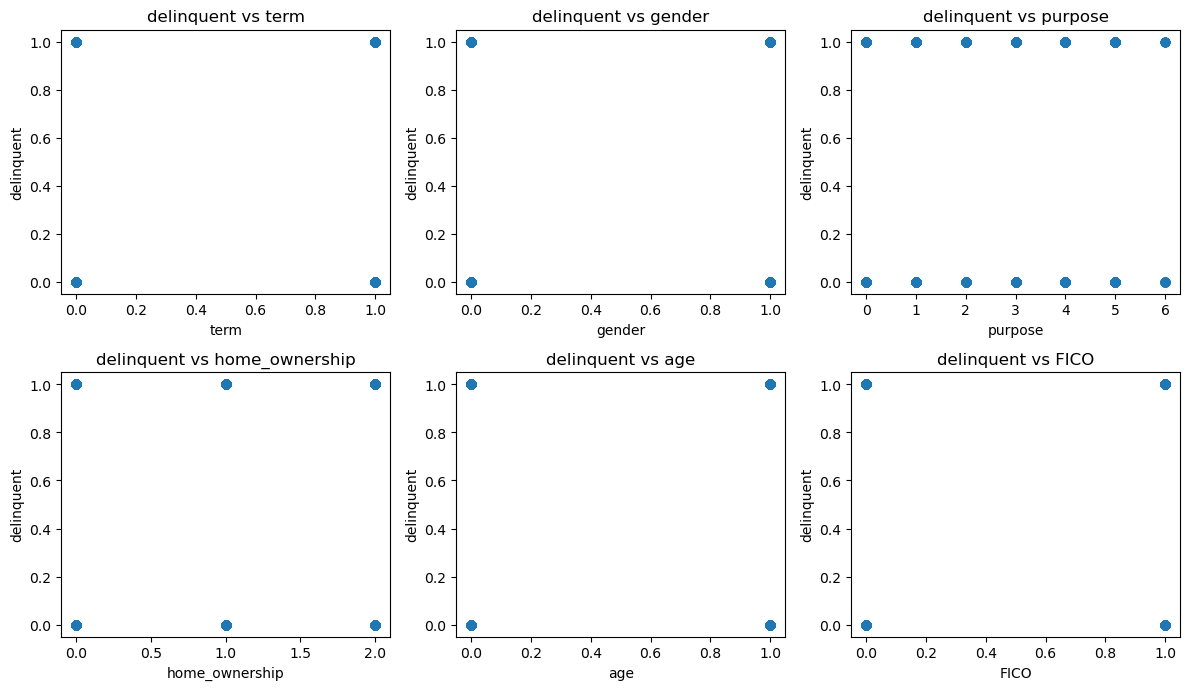

In [12]:
import matplotlib.pyplot as plt

y=df["Sdelinquent"]
X=df.drop("Sdelinquent", axis=1)

plt.figure(figsize=(12, 10))

for i, col in enumerate(X.columns):
    plt.subplot(3, 3, i + 1)
    plt.scatter(X[col], y)
    plt.xlabel(col)
    plt.ylabel("delinquent")
    plt.title(f"delinquent vs {col}")

plt.tight_layout()
plt.show()

In [13]:
corr = df.corr()
print(corr)

                Sdelinquent      term    gender   purpose  home_ownership  \
Sdelinquent        1.000000 -0.227456  0.072532 -0.017798        0.002451   
term              -0.227456  1.000000  0.262649  0.052666       -0.010659   
gender             0.072532  0.262649  1.000000 -0.068138        0.035470   
purpose           -0.017798  0.052666 -0.068138  1.000000       -0.104148   
home_ownership     0.002451 -0.010659  0.035470 -0.104148        1.000000   
age               -0.034327  0.079074 -0.364623  0.073096       -0.035844   
FICO              -0.432794  0.118622 -0.031348  0.031948       -0.056357   

                     age      FICO  
Sdelinquent    -0.034327 -0.432794  
term            0.079074  0.118622  
gender         -0.364623 -0.031348  
purpose         0.073096  0.031948  
home_ownership -0.035844 -0.056357  
age             1.000000  0.236542  
FICO            0.236542  1.000000  


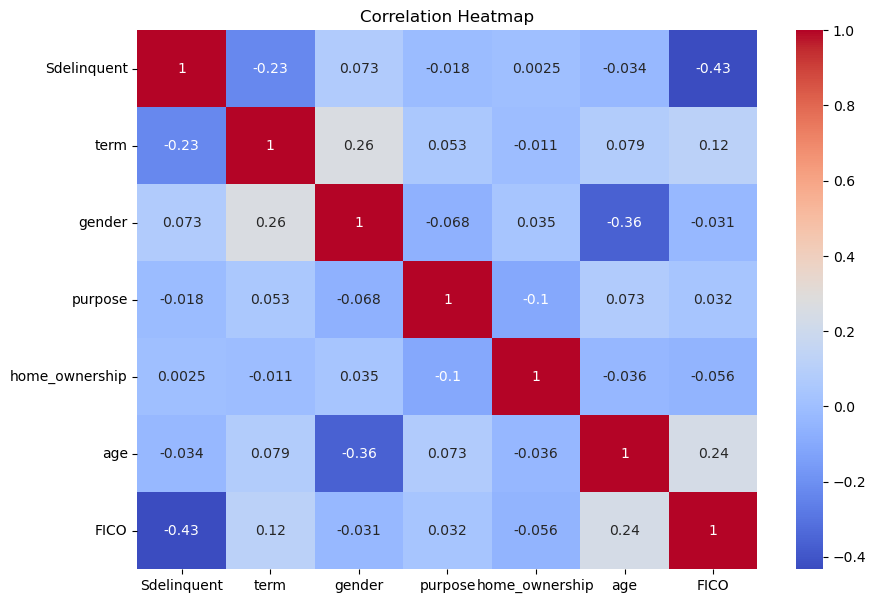

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

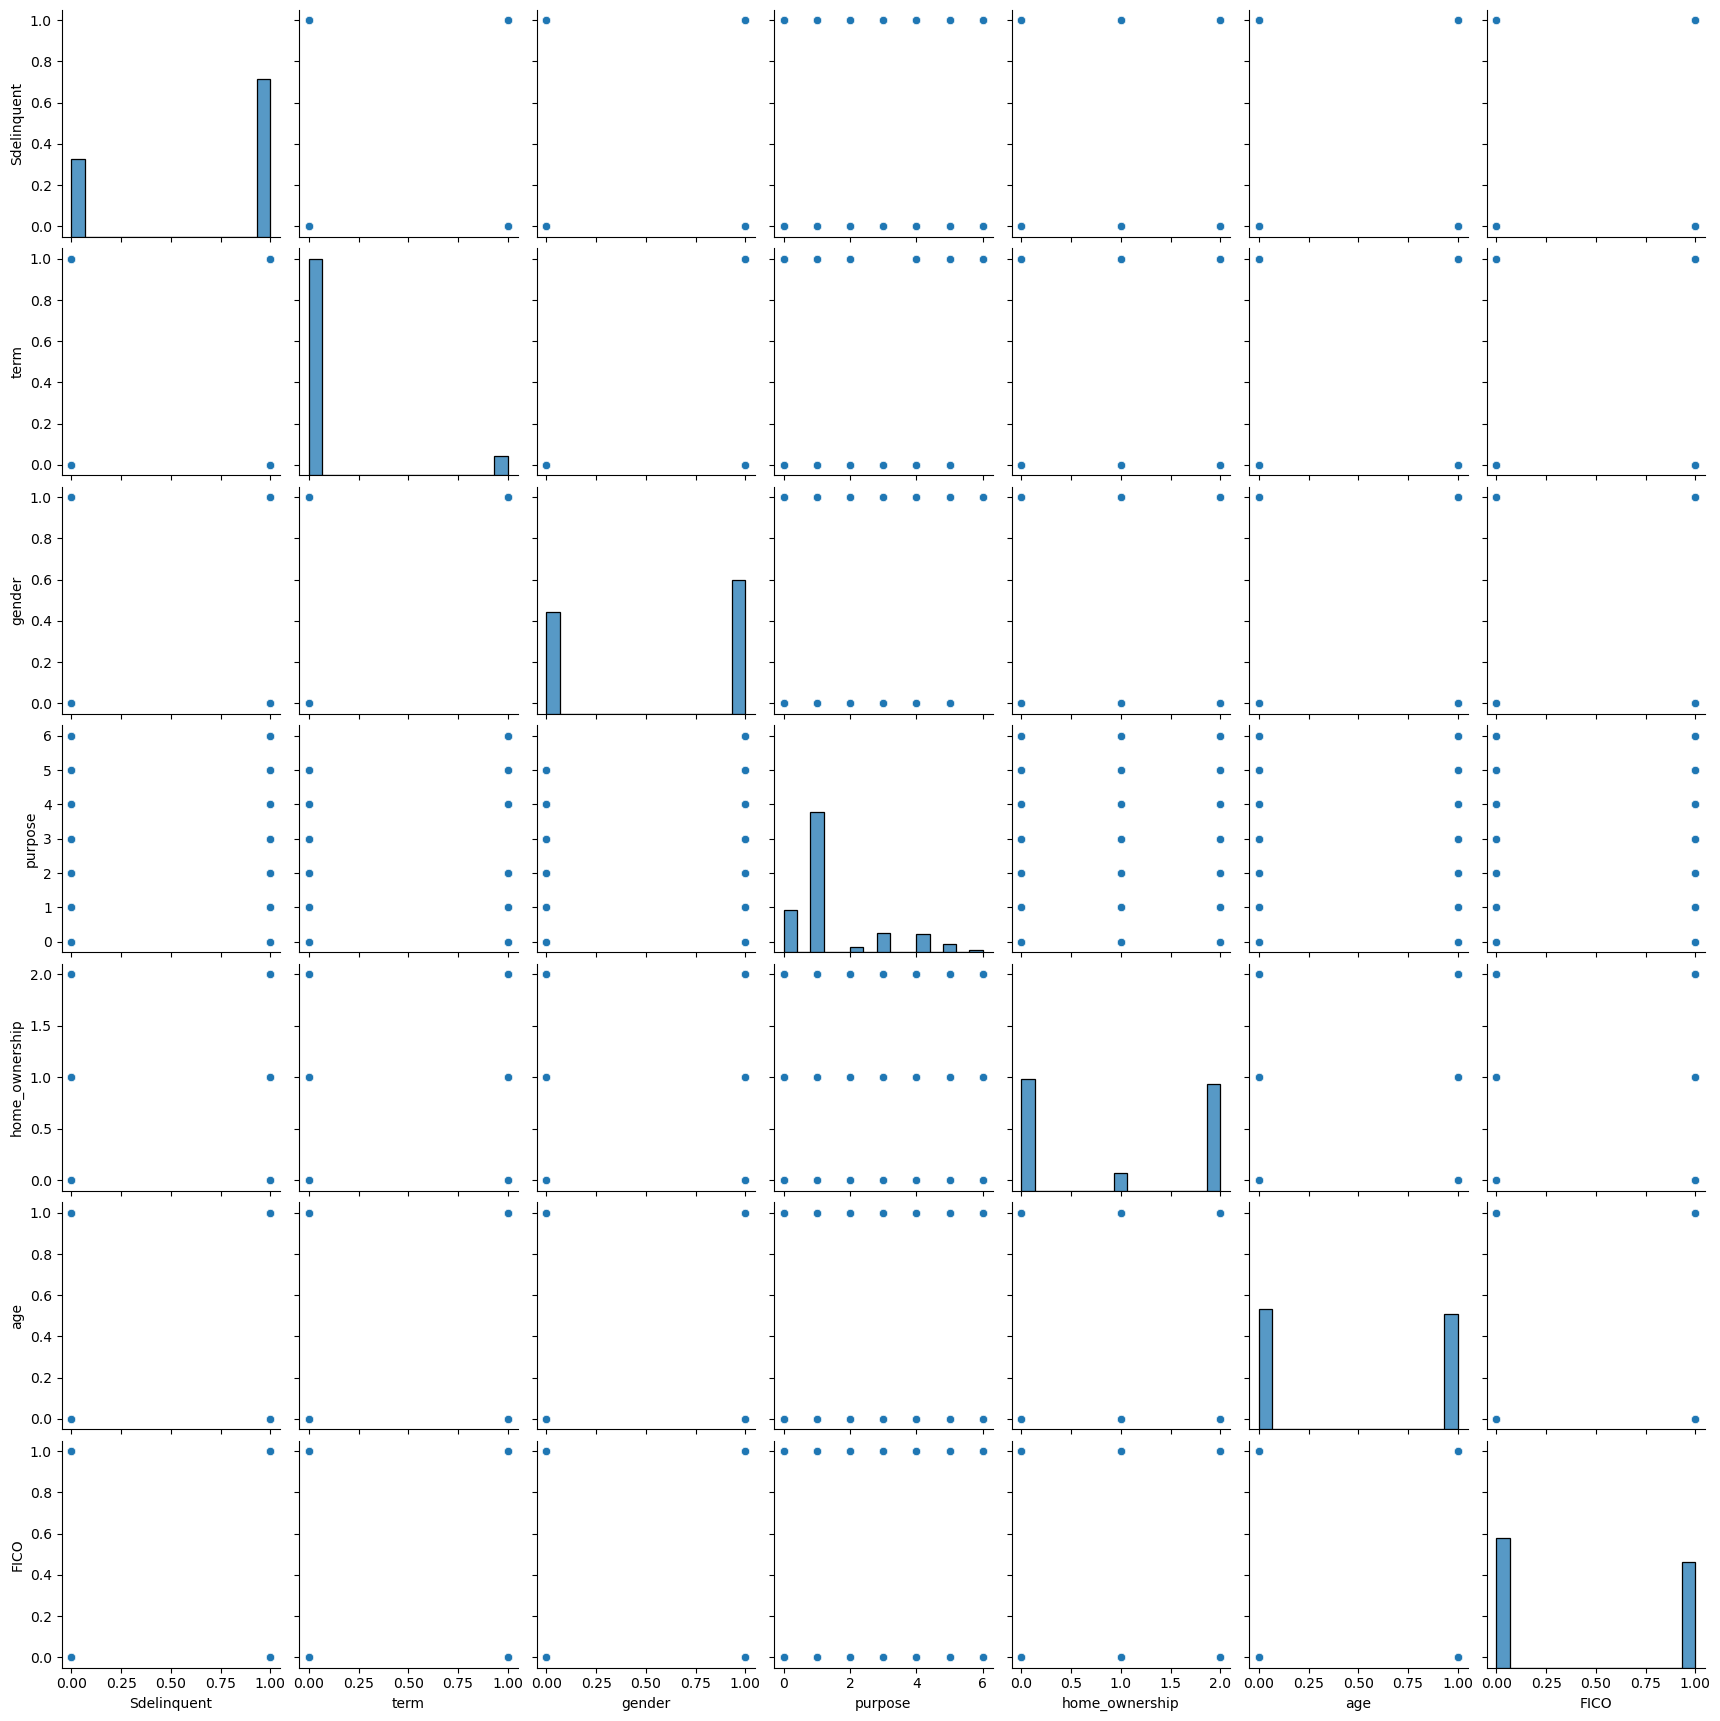

In [15]:
sns.pairplot(df)
plt.show()

In [16]:
# Define features and target variable
X = df.drop(columns=["Sdelinquent"])
y = df["Sdelinquent"]

In [17]:
from sklearn.model_selection import train_test_split
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

In [18]:
from sklearn.linear_model import LogisticRegression
# Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [19]:
# Probability prediction of logistics regression on Train data
y_train_prob=model.predict_proba(X_train) # probability of X_train
print(y_train_prob)

[[0.12724885 0.87275115]
 [0.23661388 0.76338612]
 [0.14247579 0.85752421]
 ...
 [0.12747866 0.87252134]
 [0.84674727 0.15325273]
 [0.54591709 0.45408291]]


In [20]:
# Probability prediction of logistics regression on Test data
y_test_prob=model.predict_proba(X_test) # probability of X_test
print(y_test_prob)

[[0.82901825 0.17098175]
 [0.35606164 0.64393836]
 [0.4071411  0.5928589 ]
 ...
 [0.54286849 0.45713151]
 [0.12724885 0.87275115]
 [0.12343327 0.87656673]]


In [21]:
# manually setting a threshold value of 0.7 ( by default its 0.5)
y_train_pred_thres=(y_train_prob[:,1]>=0.7).astype(int)
# changing threshold to 0.7
y_train_pred_thres

array([1, 1, 1, ..., 1, 0, 0])

In [22]:
# Predict on train and test data
y_train_pred = model.predict(X_train)# default threshold value = 0.5
print(y_train_pred)
# predict on test data
y_test_pred = model.predict(X_test)

[1 1 1 ... 1 0 0]


-- Model Performance Measure --

In [23]:
from sklearn.metrics import confusion_matrix,classification_report
train_cm = confusion_matrix(y_train, y_train_pred) # (y_actual,y_predict)
train_report = classification_report(y_train, y_train_pred)
print(train_report)
print(train_cm)

              precision    recall  f1-score   support

           0       0.72      0.66      0.69      3063
           1       0.84      0.87      0.85      6175

    accuracy                           0.80      9238
   macro avg       0.78      0.77      0.77      9238
weighted avg       0.80      0.80      0.80      9238

[[2026 1037]
 [ 806 5369]]


In [24]:
acc_train=(2026+5369)/(2026+5369+1037+806)
print(acc_train)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Train Precision: {train_precision:.2f}")
print(f"Train Recall: {train_recall:.2f}")

0.8004979432777658
Train Accuracy: 0.80
Train Precision: 0.84
Train Recall: 0.87


In [25]:
# Evaluate the model in train data'' program
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score, roc_curve
train_cm = confusion_matrix(y_train, y_train_pred) # (y_actual,y_predict)
train_report = classification_report(y_train, y_train_pred)
roc_auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]) #proba of class1
# roc- receiver operating characteristics , auc - area under the curve
# It is a plot between True positive rate ( Recall) and
# False Positive Rate ( 1-Specificity)
# For best model auc-roc value should be close to 1


ROC-AUC CURVE: RECEIVER OPERATOR CHARACTERSTICS AREA UNDER THE CURVE -- IT IS A CURVE PLOTTED BETWEEN TRUE POSITVE RATE (TPR) IN Y AXIS AND FALSE POSITVE RATE (FPR) IN X AXIS

In [26]:
# Evaluate the model in test data'' program
from sklearn.metrics import confusion_matrix,classification_report, roc_auc_score, roc_curve
test_cm = confusion_matrix(y_test, y_test_pred)
test_report = classification_report(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])


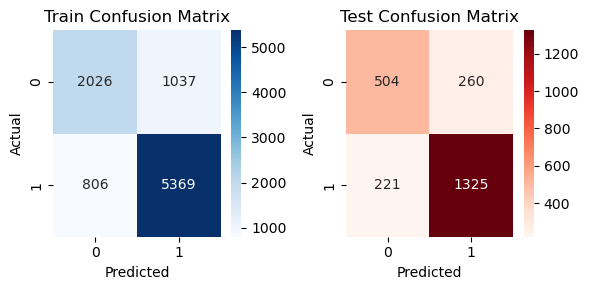

In [27]:
# confusion matrix training:
# Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Train Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.subplot(1, 2, 2)
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Reds')
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

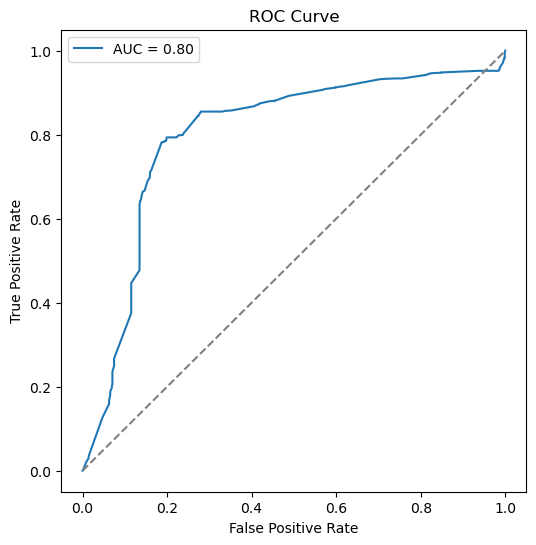

In [28]:
# Area under the Curve of Receiver Operator Characteristics.
# Plot ROC Curve
fpr, tpr,thresholds= roc_curve(y_test, model.predict_proba(X_test)[:, 1])
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_test:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [29]:
# Display evaluation results
print(train_report)
print(test_report)
print(roc_auc_train)
print(roc_auc_test)

              precision    recall  f1-score   support

           0       0.72      0.66      0.69      3063
           1       0.84      0.87      0.85      6175

    accuracy                           0.80      9238
   macro avg       0.78      0.77      0.77      9238
weighted avg       0.80      0.80      0.80      9238

              precision    recall  f1-score   support

           0       0.70      0.66      0.68       764
           1       0.84      0.86      0.85      1546

    accuracy                           0.79      2310
   macro avg       0.77      0.76      0.76      2310
weighted avg       0.79      0.79      0.79      2310

0.805202250710782
0.7992810360125437


# Model Evaluation Summary
1. Confusion Matrix:

a. Train Set:

    True Negatives: 2026
    False Positives: 1037
    False Negatives: 806
    True Positives: 5369
b. Test Set

    True Negatives: 504
    False Positives: 260
    False Negatives: 221
    True Positives: 1325

# 2. Classification Report:

Accuracy :

    Train Accuracy: 80%
    Test Accuracy: 79%

Precision (Test Set):

    Class 0 (Non-Delinquent): 70%
    Class 1 (Delinquent): 84%

Recall (Test Set):

    Class 0: 66%
    Class 1: 86%

F1-score (Test Set):

    Class 0: 68%
    Class 1: 85%

3. ROC-AUC Score: 0.80 (Good predictive capability)

# Interpretation & Recommendations:
## Performance:

    The model has good accuracy (~79-80%) and a high recall for predicting loan delinquency (86%).

    However, the precision for non-delinquent loans (70%) is lower, meaning there are more false positives (loans wrongly classified as delinquent).

## Business Implications:

    A high recall for delinquency prediction is useful for risk assessment, as it helps in identifying most defaulters.

    However, false positives (customers wrongly classified as delinquent) might lead to unnecessary loan rejections.

## Improvements:

    Feature Engineering: Add more predictive variables like income level, employment stability, etc.

    Handling Class Imbalance: If delinquent cases dominate, try SMOTE (Synthetic Minority Over-sampling Technique).

    Hyperparameter Tuning: Optimize C parameter in Logistic Regression for better precision-recall tradeoff.

    Try Other Models: Decision Trees, Random Forest, or XGBoost might improve performance.

In [31]:
result_df = pd.DataFrame(X_train)
result_df['y_train'] = y_train
result_df['y_train_pred'] = y_train_pred
result_df

,term,gender,purpose,home_ownership,age,FICO,y_train,y_train_pred
7460,0,0,1,0,1,0,1,1
5969,0,0,1,2,0,0,1,1
8902,0,0,1,2,1,0,1,1
7952,0,0,5,2,1,1,0,0
6482,1,1,1,2,0,1,1,0
...,...,...,...,...,...,...,...,...
11284,0,1,1,2,0,0,0,1
5191,0,1,0,2,1,1,1,1
5390,0,1,0,2,0,0,1,1
860,1,1,1,2,1,1,0,0
